# ARCH and GARCH Models

## ARCH Processes

### Definition
An Autoregressive Conditional Heteroskedasticity process of order $p$, denoted $ARCH(p)$, models time-varying volatility where the conditional variance depends on past squared errors.

### Mathematical Formulation
The $ARCH(p)$ model is:
$$
y_t = \mu + \varepsilon_t
$$
$$
\varepsilon_t = \sigma_t z_t
$$
where the conditional variance is:
$$
\sigma_t^2 = \omega + \alpha_1 \varepsilon_{t-1}^2 + \alpha_2 \varepsilon_{t-2}^2 + \dots + \alpha_p \varepsilon_{t-p}^2
$$
where:
- $y_t$ is the observed value at time $t$
- $\mu$ is the mean
- $\sigma_t^2$ is the conditional variance at time $t$
- $z_t$ is a white noise term with unit variance
- $\varepsilon_{t-i}^2$ are past squared innovations
- $\omega > 0$ and $\alpha_i \geq 0$ are parameters

### Stationarity and Non-negativity
For stationarity of the variance, we require $\sum_{i=1}^{p} \alpha_i < 1$. The constraint $\alpha_i \geq 0$ ensures the conditional variance is always non-negative.

## GARCH Processes

### Definition
A Generalized Autoregressive Conditional Heteroskedasticity process of order $(p, q)$, denoted $GARCH(p, q)$, extends ARCH by adding lagged conditional variances, improving parsimony and flexibility.

### Mathematical Formulation
The $GARCH(p, q)$ model is:
$$
y_t = \mu + \varepsilon_t
$$
$$
\varepsilon_t = \sigma_t z_t
$$
where the conditional variance is:
$$
\sigma_t^2 = \omega + \sum_{i=1}^{p} \alpha_i \varepsilon_{t-i}^2 + \sum_{j=1}^{q} \beta_j \sigma_{t-j}^2
$$
where:
- $\alpha_i$ are ARCH coefficients (impact of past shocks)
- $\beta_j$ are GARCH coefficients (persistence of volatility)
- $\varepsilon_{t-i}^2$ are past squared innovations
- $\sigma_{t-j}^2$ are past conditional variances

### Properties
- More parsimonious than ARCH: fewer parameters needed to capture volatility dynamics.
- $\sum_{i=1}^{p} \alpha_i + \sum_{j=1}^{q} \beta_j < 1$ ensures stationarity of the variance process.
- Captures volatility clustering: large shocks lead to sustained high volatility.
- Mean reversion: volatility reverts to long-run average level.

## Key Differences

| Feature | ARCH(p) | GARCH(p,q) |
|---------|---------|-----------|
| Conditional variance depends on | Past squared errors only | Past squared errors + past variances |
| Flexibility | Limited | Higher |
| Parsimony | Lower | Higher |
| Practical use | Rarely used alone | Standard in practice |

## Practical Use
GARCH models are widely used in financial markets to:
- forecast volatility and Value at Risk,
- price derivatives,
- estimate time-varying risk measures,
- model assets with volatility clustering.

Model identification involves selecting $p$ and $q$, estimating parameters via maximum likelihood, and validating standardized residuals for whiteness and absence of remaining volatility clustering.

# Summary
- ARCH models condition variance on past squared errors.
- GARCH extends ARCH by adding lagged conditional variances for greater flexibility.
- Both capture the stylized fact of volatility clustering in financial data.
- GARCH is the standard approach in empirical finance applications.

ARCH(1) risultati
                      Constant Mean - ARCH Model Results                      
Dep. Variable:                  ^GSPC   R-squared:                       0.000
Mean Model:             Constant Mean   Adj. R-squared:                  0.000
Vol Model:                       ARCH   Log-Likelihood:               -3219.59
Distribution:                  Normal   AIC:                           6445.18
Method:            Maximum Likelihood   BIC:                           6462.35
                                        No. Observations:                 2263
Date:                Tue, Jun 02 2026   Df Residuals:                     2262
Time:                        00:02:49   Df Model:                            1
                                Mean Model                                
                 coef    std err          t      P>|t|    95.0% Conf. Int.
--------------------------------------------------------------------------
mu             0.0965  2.080e-02      4.641  3

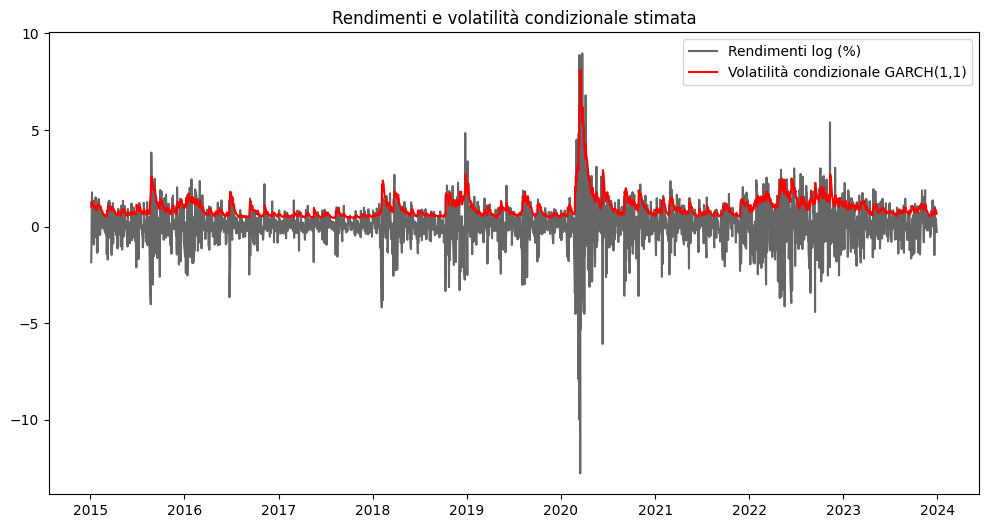

In [3]:
import numpy as np
import pandas as pd
import yfinance as yf
from arch import arch_model

import matplotlib.pyplot as plt

# Scarichiamo dati reali, ad esempio l'indice S&P 500
ticker = "^GSPC"
data = yf.download(ticker, start="2015-01-01", end="2024-01-01", progress=False)

# Calcoliamo i rendimenti logaritmici percentuali
returns = 100 * np.log(data["Close"] / data["Close"].shift(1))
returns = returns.dropna()
returns.name = "returns"

# Stima ARCH(1)
arch_model_1 = arch_model(returns, vol="ARCH", p=1, o=0, q=0, dist="normal")
arch_res_1 = arch_model_1.fit(update_freq=5, disp="off")
print("ARCH(1) risultati")
print(arch_res_1.summary())

# Stima GARCH(1,1)
garch_model_11 = arch_model(returns, vol="GARCH", p=1, o=0, q=1, dist="normal")
garch_res_11 = garch_model_11.fit(update_freq=5, disp="off")
print("\nGARCH(1,1) risultati")
print(garch_res_11.summary())

# Grafico dei rendimenti e della volatilità condizionale stimata
plt.figure(figsize=(12, 6))
plt.plot(returns.index, returns, label="Rendimenti log (%)", color="black", alpha=0.6)
plt.plot(
    returns.index,
    garch_res_11.conditional_volatility,
    label="Volatilità condizionale GARCH(1,1)",
    color="red",
)
plt.title("Rendimenti e volatilità condizionale stimata")
plt.legend()
plt.show()